# Introduction to Neural Networks

---

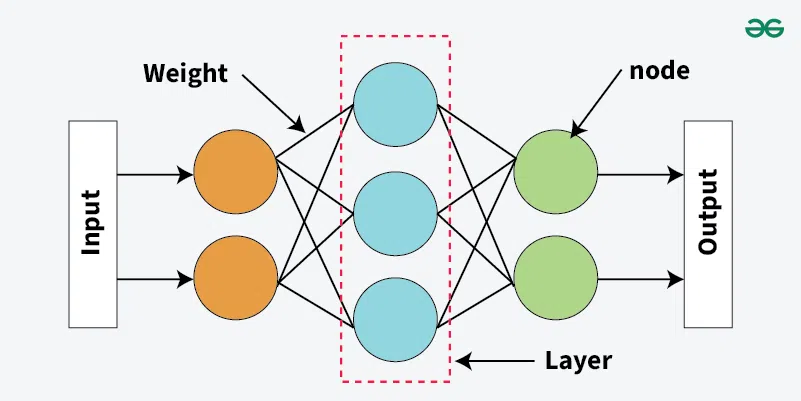

*img src: GeeksforGeeks*

This is a basic structure of a neural network. Those orange circles are the inputs, where we feed our data to the model. Layer of blue circles is a hidden layer. And the one with green circle is output layer. A individual circle you can see in layers except input layer is called a node/ neuron. You could see black lines joining all nodes to each other. These are called weights/ parameters.

Neural Networks do not work out of nowhere. It isn't magic, but rather a of mathematical calculations.

---

$$Y = mX + b$$

This is basic linear funstion we learned in high school. A hidden layer in Neural Network actually difined by the linear function. However, it uses matrices which is quite different than using scalars during high school.

Let's write the function as,

$$Z(X) = θX + β$$

Where,

Z(X) = Output of Layer

X = Inputs to the layer/ output of previous layer

θ = Weights

β = Biases, a bias is a scalar to be added to output of a individual layer. Each layer has `n_nodes x 1` bias terms.

---

Let's consider a Neural Network with `n` layers, where, `1 of them` is Output layer and `n-1` is number of hidden layers.

Let the output of layer `n` be denoted by $Z_n$

 $$Z_n(X) = θ_nX + β_n$$

---

Now, the model can be defined as,

$$Z(X) = Z_1(Z_2(Z_3(...Z_{n-2}(Z_{n-1}))))$$

                        

However, since the layers are linear functions, to add non-linearity to the Neural Network, we use some activation function $\sigma(Z)$, so the final model will be something like:

$$Z(X) = Z_{n}(\space\sigma(\space Z_{n-1}(\space...\sigma(\space Z_2(\space\sigma (Z_1(\space X)\space))))))$$


<br>
(Note: This is just for intuition, it is not like you should use activations all the time)

---

## Here is a small code piece for chained linear function

In [1]:
import numpy as np

In [31]:
def linear(x, theta, beta):
  return (theta@x.T).T + beta   #@ is operation for dot product in numpy and .T transposes the matrix

In [32]:
#Let's create a model, where, the shape of input is (samples, 2), providing only one sample, it will be (1, 2)
#We will define one hidden layer with shape (1, 3) which means number of nodes in hidden layer is 3. Weights from input layer to hidden layer will be (3, 2)
#We will then define output layer whole shape is (1, 1), then the shape of weight from 2nd layer to output layer will be (1, 3)
#This means, a model will take 2 input at a time and produce one output.

#Summary:
# Input layer (1 x 2)
#    |
#    |      theta1 = (3 x 2)
#    |
# Hidden layer Z1 (3 x 2) @ (1 x 2).T  =  (1 x 3)
#    |
#    |      theta2 = (1 x 3)
#    |
# Output layer Z2/ Zn = (3 x 2) @ (1 x 2).T  =  (1 x 3)
#
# The architecture is basically the same as the figure above except it has only one node in output layer



### Without activations

In [33]:
X = np.array([[5, 6]]) # Input of shape (1, 2) , where 1 is number of sample and 2 is number of features provided

In [34]:
X.shape

(1, 2)

In [55]:
def model_na(x):
  # Lets define some random weights and biases

  #for hidden layer
  theta1 = np.array([[2.09, 3], [-5, -2.1], [1, 2.4]])
  beta1 = np.array([3.5, -2.4, 1.3])

  #for output layer
  theta2 = np.array([[3.1, 0.22, 5.02]])
  beta2 = np.array([5])

  #now layers
  z1 = linear(x, theta1, beta1)
  z2 = linear(z1, theta2, beta2)

  return z2


In [56]:
model_na(X)

array([[199.159]])

---

### Using activations

In [43]:
def relu(x):   #A simple implementation of ReLU activation function
  return np.clip(x, 0, None)

In [57]:
def model_a(x):
  theta1 = np.array([[2.09, 3], [-5, -2.1], [1, 2.4]])
  beta1 = np.array([3.5, -2.4, 1.3])

  theta2 = np.array([[3.1, 0.22, 5.02]])
  beta2 = np.array([5])

  z1 = linear(x, theta1, beta1)
  z1 = relu(z1)
  z2 = linear(z1, theta2, beta2)
  z2 = relu(z2)

  return z2


In [58]:
model_a(X)

array([[207.959]])

Here, output is different because ReLU clips negative values to `0`, so we don't deal with negative terms, so output is greater than that of without relu.